In [ ]:
import pandas as pd

In [6]:
df1 = pd.read_csv("games_march2025_cleaned.csv")

df2 = pd.read_csv("extended_dataset_2.csv")

C:\Users\themi\AppData\Local\Temp\ipykernel_2316\2730073773.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("extended_dataset_2.csv")


In [7]:
df1.columns

Index(['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count',
       'detailed_description', 'about_the_game', 'short_description',
       'reviews', 'header_image', 'website', 'support_url', 'support_email',
       'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url',
       'achievements', 'recommendations', 'notes', 'supported_languages',
       'full_audio_languages', 'packages', 'developers', 'publishers',
       'categories', 'genres', 'screenshots', 'movies', 'user_score',
       'score_rank', 'positive', 'negative', 'estimated_owners',
       'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks', 'discount',
       'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total',
       'pct_pos_recent', 'num_reviews_recent'],
      dtype='object')

In [8]:
df2.columns

Index(['appid', 'name', 'type', 'is_free', 'release_date', 'required_age',
       'short_description', 'supported_languages', 'header_image',
       'background', 'metacritic_score', 'recommendations_total',
       'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux',
       'mat_initial_price', 'mat_final_price', 'mat_discount_percent',
       'mat_currency', 'mat_achievement_count', 'mat_pc_os_min',
       'mat_pc_processor_min', 'mat_pc_memory_min', 'mat_pc_graphics_min',
       'mat_pc_os_rec', 'mat_pc_processor_rec', 'mat_pc_memory_rec',
       'mat_pc_graphics_rec', 'created_at', 'updated_at', 'min_storage',
       'rec_storage', 'og_string'],
      dtype='object')

In [9]:
matching_df1 = df1[df1["appid"].isin(df2["appid"])]

print("Number of matching rows:", len(matching_df1))

Number of matching rows: 88462


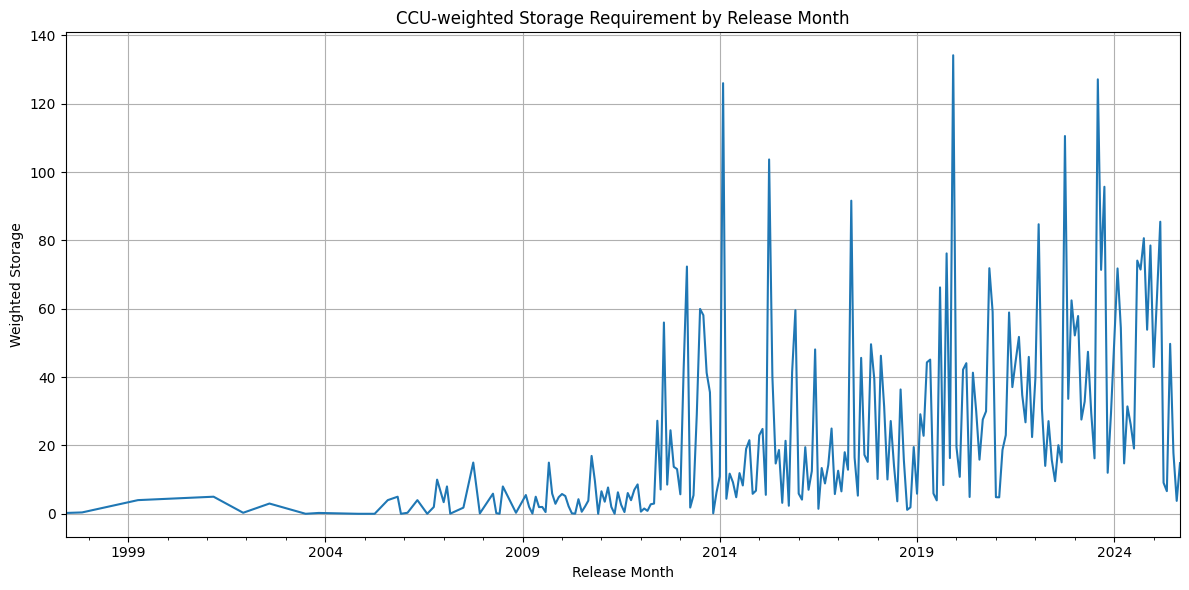

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Merge on appid
df = df2.merge(df1[['appid', 'peak_ccu']], on='appid', how='inner')

# Parse release date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Remove rows with invalid dates
df = df.dropna(subset=['release_date'])

# Convert storage columns to numeric
df['min_storage'] = pd.to_numeric(df['min_storage'], errors='coerce')
df['rec_storage'] = pd.to_numeric(df['rec_storage'], errors='coerce')

# Smaller of min_storage and rec_storage
df['storage'] = np.minimum(df['min_storage'], df['rec_storage'])

# If one is missing and the other exists
df['storage'] = df[['min_storage', 'rec_storage']].min(axis=1)

# Month-Year bucket
df['month'] = df['release_date'].dt.to_period('M')

# Sum peak_ccu within each month
monthly_peak_ccu = df.groupby('month')['peak_ccu'].transform('sum')

# Compute weighted storage contribution
df['weighted_storage'] = (
    df['peak_ccu'] * df['storage'] / monthly_peak_ccu
)

# Sum weighted contributions by month
monthly_weighted_storage = (
    df.groupby('month')['weighted_storage']
      .sum()
      .sort_index()
)

# Plot
plt.figure(figsize=(12,6))
monthly_weighted_storage.plot()
plt.title('CCU-weighted Storage Requirement by Release Month')
plt.xlabel('Release Month')
plt.ylabel('Weighted Storage')
plt.grid(True)
plt.tight_layout()
plt.show()

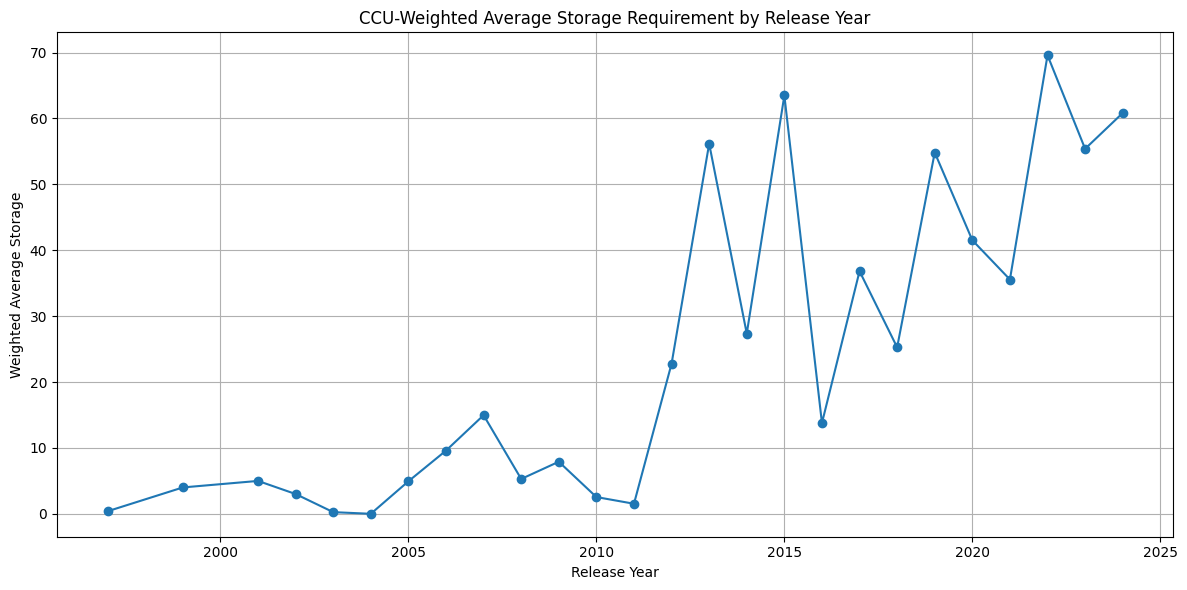

year
1997     0.389565
1999     4.000000
2001     4.988675
2002     3.000000
2003     0.250000
2004     0.000000
2005     4.934545
2006     9.591232
2007    14.963390
2008     5.284500
2009     7.902220
2010     2.541291
2011     1.524382
2012    22.776125
2013    56.156909
2014    27.351828
2015    63.486309
2016    13.771303
2017    36.815456
2018    25.260325
2019    54.822006
2020    41.516702
2021    35.552640
2022    69.585381
2023    55.389003
2024    60.821915
dtype: float64


In [11]:
# Year
df['year'] = df['release_date'].dt.year

# Keep only 2024 and earlier
df_year = df[df['year'] <= 2024]

# CCU-weighted average storage by year
yearly_storage = (
    df_year.groupby('year')
           .apply(lambda g: (g['storage'] * g['peak_ccu']).sum()
                            / g['peak_ccu'].sum())
)

# Plot
plt.figure(figsize=(12, 6))
yearly_storage.plot(marker='o')
plt.title('CCU-Weighted Average Storage Requirement by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Weighted Average Storage')
plt.grid(True)
plt.tight_layout()
plt.show()

print(yearly_storage)